In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [ ]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/ct_reconstruction_dataset_128",
    sinogram_shape=(256, 183),
    image_shape=(128, 128),
    parts_len={"train": 206143, "validation": 25767, "test": 25769},
    impl="skimage",
)

test_dataset = dataset.create_torch_dataset(part="test")

In [ ]:
batch_size = 8

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [8]:
from models.Pix2Pix_128 import UnetGenerator

In [10]:
generator = UnetGenerator().to(device)

checkpoint = torch.load("../models/128x128_1412_pix2pix.pth", map_location=device)

generator.load_state_dict(checkpoint)

<All keys matched successfully>

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters:", count_parameters(generator))

Number of trainable parameters: 36894721


In [12]:
import math
import numpy as np


def calculate_psnr(img1, img2, max_val=1.0):
    img1_np = img1.squeeze().cpu().numpy()
    img2_np = img2.squeeze().cpu().numpy()
    mse = np.mean((img1_np - img2_np) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * math.log10(max_val) - 10 * math.log10(mse)


def calculate_mse(img1, img2):
    return F.mse_loss(img1, img2).item()


def calculate_ssim(img1, img2):
    img1_np = img1.squeeze().cpu().numpy()
    img2_np = img2.squeeze().cpu().numpy()
    ssim_value = ssim(img1_np, img2_np, data_range=img1_np.max() - img1_np.min())
    # Ensure we return only the scalar score.
    if isinstance(ssim_value, (tuple, list)):
        ssim_value = ssim_value[0]
    return float(ssim_value)

In [13]:
def hu_window(tensor, a=-200, b=200):
    # tensor in (0,1) representing HU [-1024, 3071]
    hu = tensor * (3071 + 1024) - 1024
    hu = torch.clamp(hu, a, b)
    hu = (hu - a) / (b - a)
    return hu

In [ ]:
generator.eval()

mse_test = 0.0
ssim_test = 0.0
psnr_test = 0.0

window_mse_test = 0.0
window_ssim_test = 0.0
window_psnr_test = 0.0

with torch.no_grad():
    for sino, img in test_loader:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        img_window = hu_window(img, a=-100, b=100)

        output = generator(sino)
        window_output = hu_window(output, a=-100, b=100)

        mse_test += calculate_mse(img, output)
        window_mse_test += calculate_mse(img_window, window_output)

        ssim_test += calculate_ssim(img, output)
        window_ssim_test += calculate_ssim(img_window, window_output)

        psnr_test += calculate_psnr(img, output, max_val=1.0)
        window_psnr_test += calculate_psnr(img_window, window_output, max_val=1.0)

    mse_test /= len(test_loader)
    ssim_test /= len(test_loader)
    psnr_test /= len(test_loader)
    window_mse_test /= len(test_loader)
    window_ssim_test /= len(test_loader)
    window_psnr_test /= len(test_loader)

print(
    f"Losses: "
    f"Test Loss: {mse_test:.6f} | "
    f"Test SSIM: {ssim_test:.4f} | "
    f"Test PSNR: {psnr_test:.4f}"
)
print(
    f"Windowed Losses: "
    f"Test Loss: {window_mse_test:.6f} | "
    f"Test SSIM: {window_ssim_test:.4f} | "
    f"Test PSNR: {window_psnr_test:.4f}"
)

KeyboardInterrupt: 

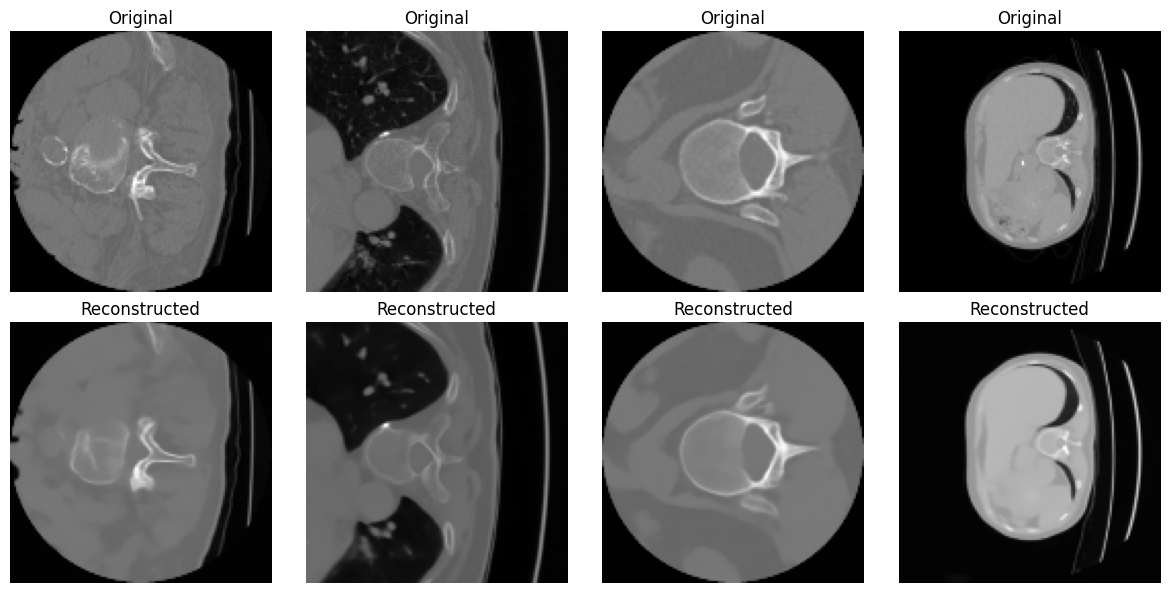

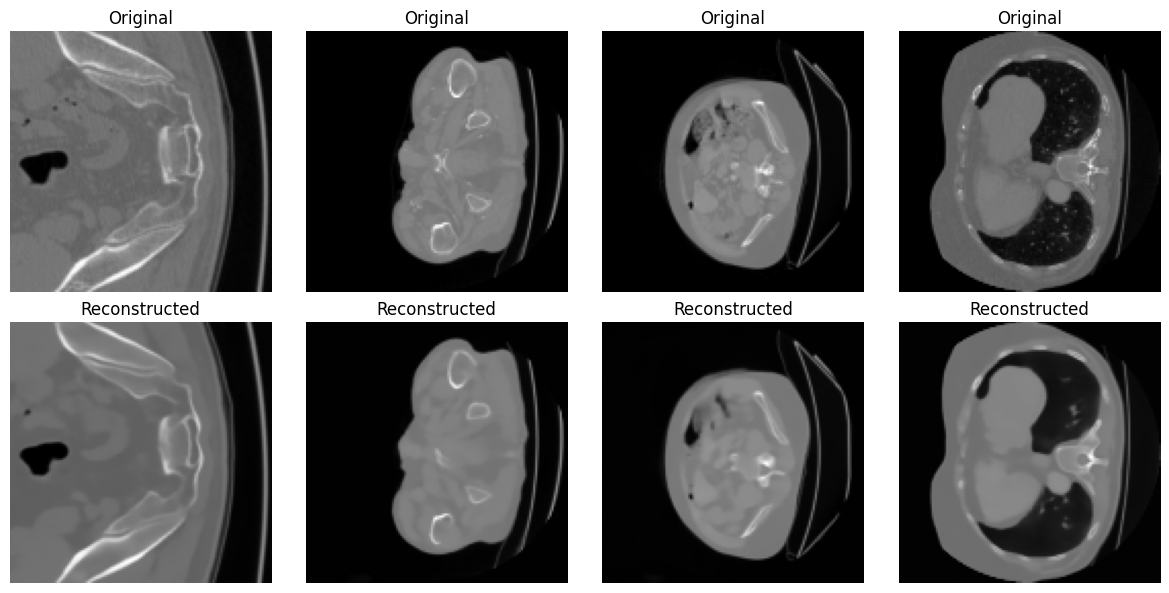

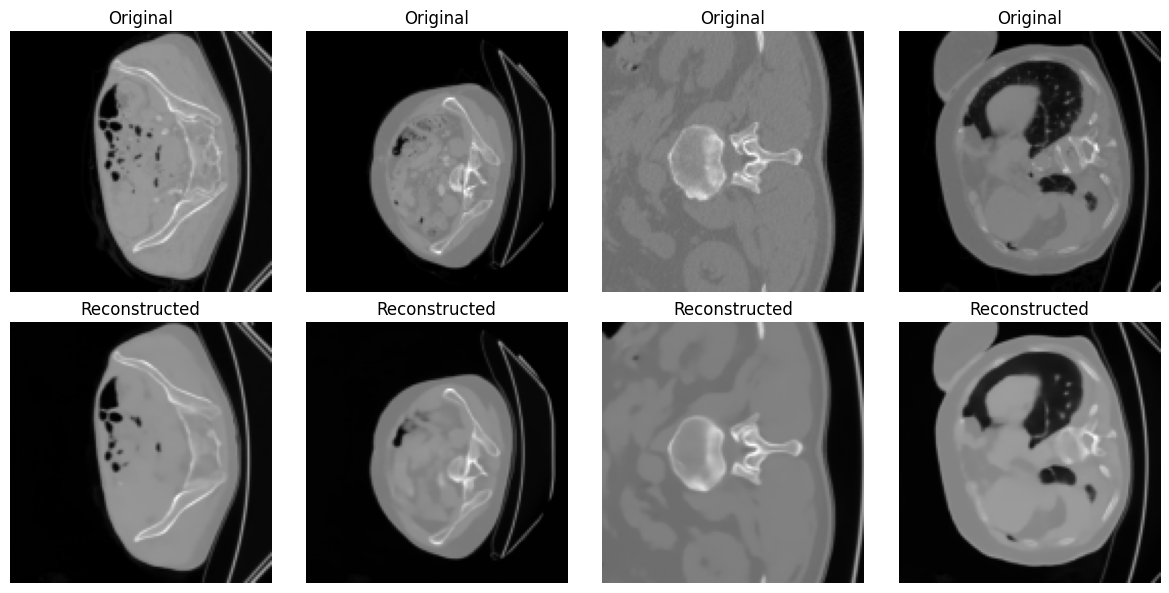

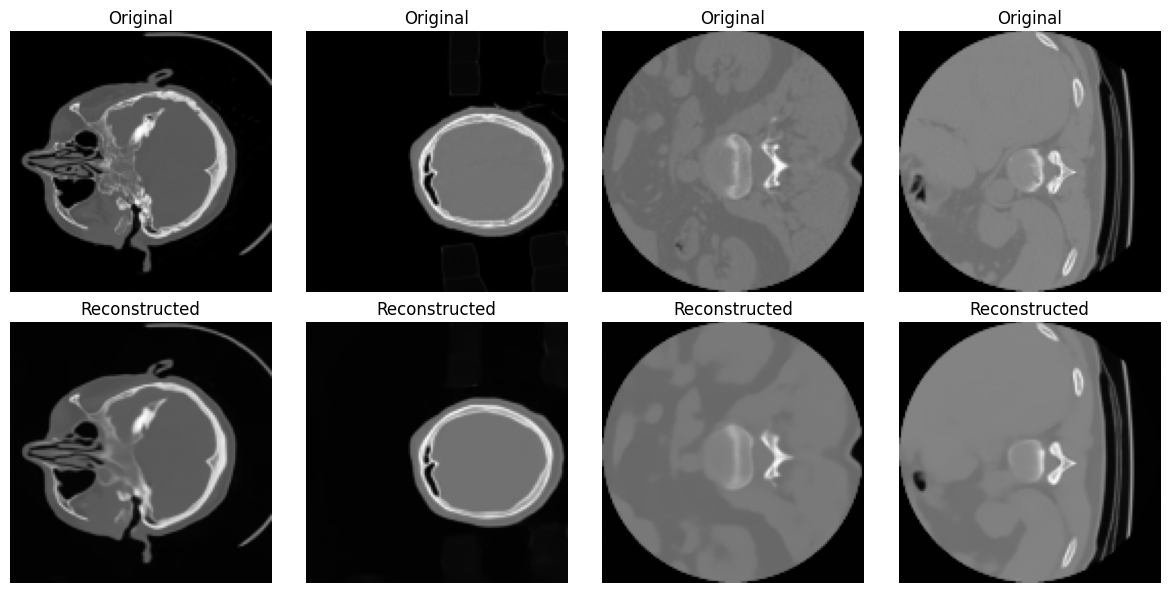

Average inference time per image: 5.26 milliseconds


In [19]:
import matplotlib.pyplot as plt
import time


def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    inference_times = []
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            start_time = time.time()
            output = model(sino)
            end_time = time.time()
            inference_times.append(end_time - start_time)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

    average_inference_time = sum(inference_times) / len(inference_times)
    print(
        f"Average inference time per image: {(1000 * average_inference_time / batch_size):.2f} milliseconds"
    )


show_reconstructed_images(generator, test_loader, device, num_images=16)

### Klasyczna rekonstrukcja - porównanie

In [16]:
import numpy as np
import astra


def reconstruct_image_from_sinogram(
    sinograms: np.ndarray, img_size, algorithm="FBP_CUDA"
):
    """
    Rekonstruuje batch obrazów z batcha sinogramów.

    Parametry:
        sinograms (np.ndarray): [B, A, D]
        num_angles (int): liczba kątów
        img_size (int): rozmiar obrazu wyjściowego
        algorithm (str): np. "FBP" lub "FBP_CUDA"

    Zwraca:
        np.ndarray: [B, img_size, img_size]
    """

    assert sinograms.ndim == 3, "Oczekiwany shape [B, A, D]"
    B, A, D = sinograms.shape

    # --- Geometria (wspólna dla batcha) ---
    angles = np.linspace(0, np.pi, A, endpoint=False)
    proj_geom = astra.create_proj_geom("parallel", 1.0, D, angles)
    vol_geom = astra.create_vol_geom(img_size, img_size)

    reconstructions = []

    for b in range(B):
        sino = sinograms[b]

        sino_id = astra.data2d.create("-sino", proj_geom, sino)
        reco_id = astra.data2d.create("-vol", vol_geom)

        cfg = astra.astra_dict(algorithm)
        cfg["ReconstructionDataId"] = reco_id
        cfg["ProjectionDataId"] = sino_id
        if "CUDA" not in algorithm:
            cfg["ProjectorId"] = astra.create_projector("linear", proj_geom, vol_geom)

        alg_id = astra.algorithm.create(cfg)
        astra.algorithm.run(alg_id)

        reco = astra.data2d.get(reco_id)
        reconstructions.append(reco)

        # Sprzątanie
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(sino_id)
        astra.data2d.delete(reco_id)

    return np.stack(reconstructions, axis=0)

ModuleNotFoundError: No module named 'astra'

In [109]:
with torch.no_grad():
    for sino, img in test_loader:
        sino_np = sino.detach().cpu().numpy().astype(np.float32)

        reconstruction = reconstruct_image_from_sinogram(
            sino_np, img_size=128, algorithm="FBP_CUDA"
        )